In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path("..") if Path.cwd().name == "notebooks" else Path(".")

baseline_path = BASE / "models" / "baseline_metrics.json"
baseline_no_lag_path = BASE / "models" / "baseline_no_lag_metrics.json"
lightgbm_path = BASE / "models" / "lightgbm_metrics.json"
lightgbm_full_path = BASE / "models" / "lightgbm_full_panel_metrics.json"
gmm_clusters_path = BASE / "data" / "processed" / "segment_clusters.csv"
segment_profiles_path = BASE / "data" / "processed" / "segment_profiles.csv"

In [2]:
with open(baseline_path, "r") as f:
    baseline = json.load(f)

with open(baseline_no_lag_path, "r") as f:
    baseline_no_lag = json.load(f)

with open(lightgbm_path, "r") as f:
    lightgbm = json.load(f)

with open(lightgbm_full_path, "r") as f:
    lightgbm_full = json.load(f)

clusters = pd.read_csv(gmm_clusters_path)
profiles = pd.read_csv(segment_profiles_path)

print("Loaded model outputs and cluster data.")
print("Cluster file shape:", clusters.shape)

Loaded model outputs and cluster data.
Cluster file shape: (11641, 29)


In [3]:
model_summary = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "setting": "Sampled + lag",
        "roc_auc": baseline["logistic_regression"]["roc_auc"],
        "avg_precision": baseline["logistic_regression"]["average_precision"],
    },
    {
        "model": "Random Forest",
        "setting": "Sampled + lag",
        "roc_auc": baseline["random_forest"]["roc_auc"],
        "avg_precision": baseline["random_forest"]["average_precision"],
    },
    {
        "model": "LightGBM",
        "setting": "Sampled + lag",
        "roc_auc": lightgbm["lightgbm_with_lag"]["roc_auc"],
        "avg_precision": lightgbm["lightgbm_with_lag"]["average_precision"],
    },
    {
        "model": "Logistic Regression",
        "setting": "Sampled no lag",
        "roc_auc": baseline_no_lag["logistic_no_lag"]["roc_auc"],
        "avg_precision": baseline_no_lag["logistic_no_lag"]["average_precision"],
    },
    {
        "model": "Random Forest",
        "setting": "Sampled no lag",
        "roc_auc": baseline_no_lag["rf_no_lag"]["roc_auc"],
        "avg_precision": baseline_no_lag["rf_no_lag"]["average_precision"],
    },
    {
        "model": "LightGBM",
        "setting": "Sampled no lag",
        "roc_auc": lightgbm["lightgbm_no_lag"]["roc_auc"],
        "avg_precision": lightgbm["lightgbm_no_lag"]["average_precision"],
    },
    {
        "model": "LightGBM",
        "setting": "Full panel",
        "roc_auc": lightgbm_full["test_metrics"]["roc_auc"],
        "avg_precision": lightgbm_full["test_metrics"]["average_precision"],
    },
])

model_summary

,model,setting,roc_auc,avg_precision
0,Logistic Regression,Sampled + lag,0.979517,0.984818
1,Random Forest,Sampled + lag,0.980240,0.985124
2,LightGBM,Sampled + lag,0.980923,0.985432
3,Logistic Regression,Sampled no lag,0.660869,0.602493
4,Random Forest,Sampled no lag,0.681626,0.617950
5,LightGBM,Sampled no lag,0.692215,0.626909
6,LightGBM,Full panel,0.619296,0.023968


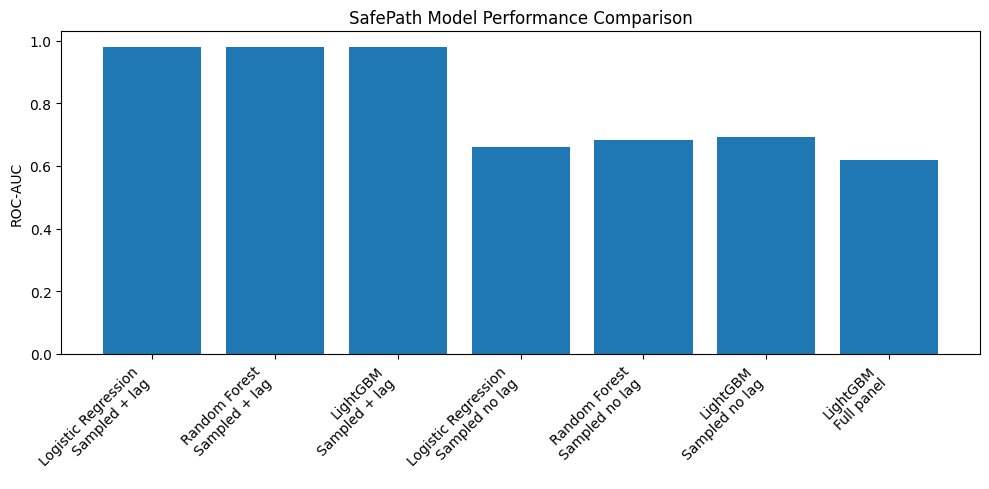

In [4]:
plot_df = model_summary.copy()
plot_df["label"] = plot_df["model"] + "\n" + plot_df["setting"]

plt.figure(figsize=(10, 5))
plt.bar(plot_df["label"], plot_df["roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("SafePath Model Performance Comparison")
plt.tight_layout()
plt.show()

In [5]:
cluster_summary = clusters.groupby("gmm_cluster").agg(
    n_segments=("segment_id", "count"),
    avg_crash_rate=("avg_crash_rate", "mean"),
    total_crashes=("total_crashes", "mean"),
    avg_crashes_last_30_days=("avg_crashes_last_30_days", "mean"),
    segment_length=("segment_length", "mean"),
).sort_values("avg_crash_rate", ascending=False)

cluster_summary

,n_segments,avg_crash_rate,total_crashes,avg_crashes_last_30_days,segment_length
gmm_cluster,,,,,
2,1332,0.038743,105.580330,1.234207,474.060951
0,972,0.027149,72.143004,0.841344,191.632845
1,2573,0.018220,47.784687,0.559225,119.074433
3,26,0.014891,38.807692,0.454394,61.446056
4,6738,0.012272,31.823093,0.372872,133.101001


In [6]:
cluster_order = cluster_summary.index.tolist()

# Adjust labels if you want after seeing more road-type detail
cluster_labels = {
    cluster_order[0]: "High-Risk Persistent Crash Zones",
    cluster_order[1]: "Elevated Risk Corridors",
    cluster_order[2]: "Moderate-Risk Segments",
    cluster_order[3]: "Low-Risk Residential Baseline",
    cluster_order[4]: "Outlier / Atypical Segments",
}

clusters["gmm_label"] = clusters["gmm_cluster"].map(cluster_labels)
cluster_summary["label"] = cluster_summary.index.map(cluster_labels)
cluster_summary

,n_segments,avg_crash_rate,total_crashes,avg_crashes_last_30_days,segment_length,label
gmm_cluster,,,,,,
2,1332,0.038743,105.580330,1.234207,474.060951,High-Risk Persistent Crash Zones
0,972,0.027149,72.143004,0.841344,191.632845,Elevated Risk Corridors
1,2573,0.018220,47.784687,0.559225,119.074433,Moderate-Risk Segments
3,26,0.014891,38.807692,0.454394,61.446056,Low-Risk Residential Baseline
4,6738,0.012272,31.823093,0.372872,133.101001,Outlier / Atypical Segments


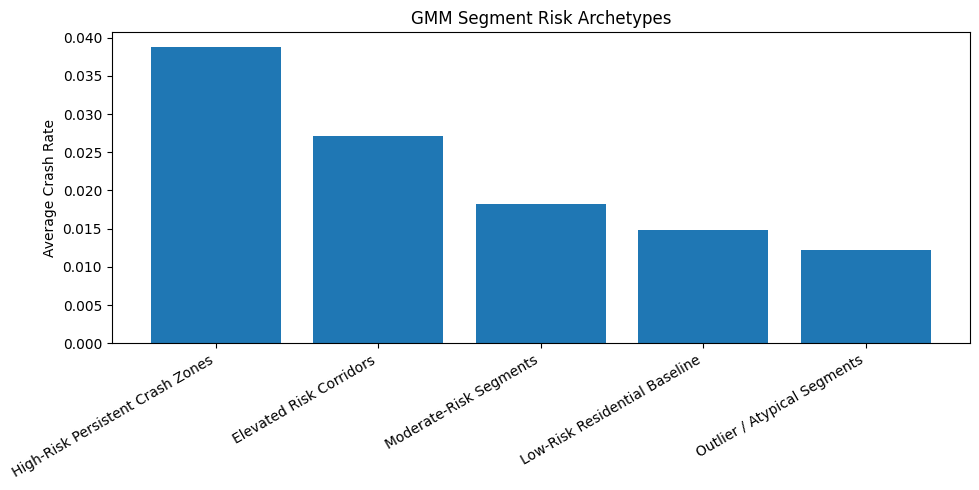

In [7]:
plot_df = cluster_summary.reset_index().sort_values("avg_crash_rate", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["label"], plot_df["avg_crash_rate"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Average Crash Rate")
plt.title("GMM Segment Risk Archetypes")
plt.tight_layout()
plt.show()

In [8]:
road_cols = [c for c in clusters.columns if c.startswith("road_")]

road_mix = clusters.groupby("gmm_cluster")[road_cols].mean()
road_mix.index = road_mix.index.map(cluster_labels)
road_mix

,road_busway,road_living_street,road_motorway,road_motorway_link,road_primary,road_primary_link,road_residential,road_secondary,road_secondary_link,road_tertiary,road_tertiary_link,road_trunk,road_trunk_link,road_unclassified
gmm_cluster,,,,,,,,,,,,,,
Elevated Risk Corridors,0.0,0.000000,0.000000,0.109053,0.000000,0.000000,0.603909,0.000000,0.0,0.192387,0.000000,0.092593,0.002058,0.000000
Moderate-Risk Segments,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
High-Risk Persistent Crash Zones,0.0,0.000000,0.525526,0.000000,0.355856,0.021772,0.000000,0.004505,0.0,0.000000,0.000000,0.000000,0.000000,0.092342
Low-Risk Residential Baseline,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
Outlier / Atypical Segments,0.0,0.001187,0.000000,0.000000,0.174978,0.000000,0.683140,0.000000,0.0,0.140398,0.000297,0.000000,0.000000,0.000000


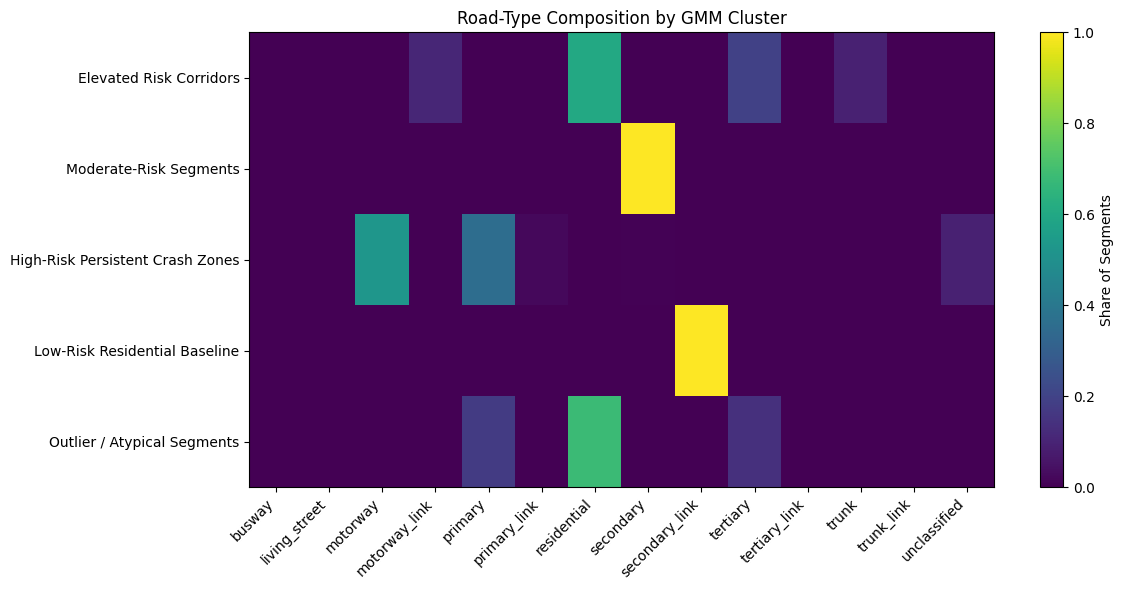

In [9]:
heatmap_df = road_mix.copy()

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels([c.replace("road_", "") for c in heatmap_df.columns], rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

ax.set_title("Road-Type Composition by GMM Cluster")
fig.colorbar(im, ax=ax, label="Share of Segments")
plt.tight_layout()
plt.show()

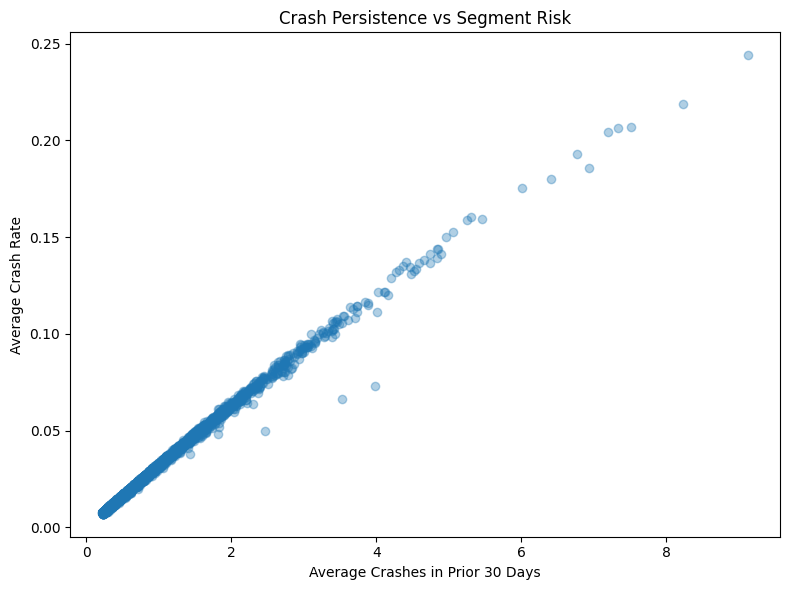

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(
    clusters["avg_crashes_last_30_days"],
    clusters["avg_crash_rate"],
    alpha=0.35
)
plt.xlabel("Average Crashes in Prior 30 Days")
plt.ylabel("Average Crash Rate")
plt.title("Crash Persistence vs Segment Risk")
plt.tight_layout()
plt.show()

In [11]:
stakeholder_metrics = pd.DataFrame([
    {
        "metric": "Test ROC-AUC",
        "value": lightgbm_full["test_metrics"]["roc_auc"],
    },
    {
        "metric": "Test Average Precision",
        "value": lightgbm_full["test_metrics"]["average_precision"],
    },
    {
        "metric": "Precision@Top 1%",
        "value": lightgbm_full["test_top_1pct"]["precision_at_k"],
    },
    {
        "metric": "Recall@Top 1%",
        "value": lightgbm_full["test_top_1pct"]["recall_at_k"],
    },
    {
        "metric": "Precision@Top 5%",
        "value": lightgbm_full["test_top_5pct"]["precision_at_k"],
    },
    {
        "metric": "Recall@Top 5%",
        "value": lightgbm_full["test_top_5pct"]["recall_at_k"],
    },
])

stakeholder_metrics

,metric,value
0,Test ROC-AUC,0.619296
1,Test Average Precision,0.023968
2,Precision@Top 1%,0.059287
3,Recall@Top 1%,0.054629
4,Precision@Top 5%,0.035267
5,Recall@Top 5%,0.162482


In [12]:
print("Key findings:")
print("- Lag-informed supervised models greatly outperform no-lag sampled baselines.")
print("- Full-panel prediction is much harder but still better than chance.")
print("- Segments cluster into distinct risk archetypes under GMM.")
print("- High-risk clusters show stronger crash persistence and higher long-run crash rates.")
print("- Road type and segment structure help explain these archetypes.")

Key findings:
- Lag-informed supervised models greatly outperform no-lag sampled baselines.
- Full-panel prediction is much harder but still better than chance.
- Segments cluster into distinct risk archetypes under GMM.
- High-risk clusters show stronger crash persistence and higher long-run crash rates.
- Road type and segment structure help explain these archetypes.


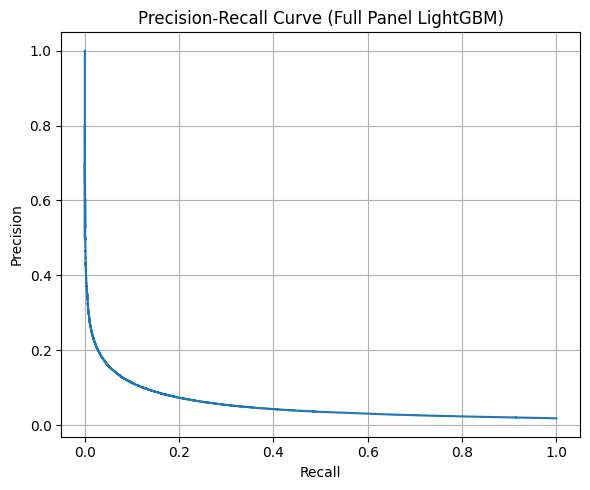

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

df = pd.read_csv("../data/processed/full_panel_predictions.csv")

y_true = df["crash_occurred"].values
y_prob = df["predicted_proba"].values

precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Full Panel LightGBM)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/segment_infrastructure_features.csv")

print(df["near_intersection"].value_counts(dropna=False))
print(df["near_traffic_signal"].value_counts(dropna=False))
print(df["near_crossing"].value_counts(dropna=False))
print(df["road_type"].value_counts().head(20))
print(df[["segment_curvature", "bearing_change_max", "intersection_degree_max"]].describe())

near_intersection
1    139028
0       163
Name: count, dtype: int64
near_traffic_signal
0    83309
1    55882
Name: count, dtype: int64
near_crossing
0    138538
1       653
Name: count, dtype: int64
road_type
residential                   89988
secondary                     16852
tertiary                      15611
primary                        9590
unclassified                   2437
motorway_link                  1727
motorway                       1140
trunk                           466
primary_link                    442
secondary_link                  338
tertiary_link                   248
living_street                   123
trunk_link                      112
residential unclassified         29
residential tertiary             15
tertiary unclassified             9
busway                            7
motorway motorway_link            7
motorway_link unclassified        6
motorway_link secondary           5
Name: count, dtype: int64
       segment_curvature  bearing_change_max

In [2]:
import pandas as pd

df = pd.read_csv("../data/processed/full_panel_features_with_infra.csv")

new_cols = [
    "lanes",
    "maxspeed",
    "oneway",
    "is_bridge",
    "is_tunnel",
    "is_junction",
    "segment_curvature",
    "bearing_change_max",
    "u_degree",
    "v_degree",
    "intersection_degree_max",
    "near_intersection",
    "near_traffic_signal",
    "near_crossing",
]

print("SHAPE")
print(df.shape)

print("\nNEW COLS NULLS")
print(df[new_cols].isna().sum().sort_values(ascending=False))

print("\nNEW COLS HEAD")
print(df[["segment_id"] + new_cols].head(10))

print("\nNEW COLS SUMMARY")
print(df[new_cols].describe(include="all"))

print("\nINDICATOR COUNTS")
for c in [
    "oneway",
    "is_bridge",
    "is_tunnel",
    "is_junction",
    "near_intersection",
    "near_traffic_signal",
    "near_crossing",
]:
    print(f"\n{c}")
    print(df[c].value_counts(dropna=False))

SHAPE
(29766037, 45)

NEW COLS NULLS
lanes                      0
maxspeed                   0
oneway                     0
is_bridge                  0
is_tunnel                  0
is_junction                0
segment_curvature          0
bearing_change_max         0
u_degree                   0
v_degree                   0
intersection_degree_max    0
near_intersection          0
near_traffic_signal        0
near_crossing              0
dtype: int64

NEW COLS HEAD
   segment_id  lanes  maxspeed  oneway  is_bridge  is_tunnel  is_junction  \
0           0    2.0      50.0       1          0          0            0   
1           0    2.0      50.0       1          0          0            0   
2           0    2.0      50.0       1          0          0            0   
3           0    2.0      50.0       1          0          0            0   
4           0    2.0      50.0       1          0          0            0   
5           0    2.0      50.0       1          0          0       

In [6]:
import pandas as pd

infra = pd.read_csv("../data/processed/segment_infrastructure_features.csv", nrows=5)
panel = pd.read_csv("../data/processed/full_panel_features_with_infra.csv", nrows=5)

print("INFRA HAS visibility_risk_score:", "visibility_risk_score" in infra.columns)
print("FULL PANEL HAS visibility_risk_score:", "visibility_risk_score" in panel.columns)

if "visibility_risk_score" in infra.columns:
    print("\nInfra visibility_risk_score summary:")
    infra_full = pd.read_csv("../data/processed/segment_infrastructure_features.csv", usecols=["visibility_risk_score"])
    print(infra_full["visibility_risk_score"].describe())

INFRA HAS visibility_risk_score: True
FULL PANEL HAS visibility_risk_score: True

Infra visibility_risk_score summary:
count    139191.000000
mean          0.116477
std           0.034642
min           0.057143
25%           0.106525
50%           0.114384
75%           0.116959
max           0.867097
Name: visibility_risk_score, dtype: float64


In [7]:

import pandas as pd

df = pd.read_csv("../data/processed/full_panel_features_with_infra.csv", nrows=5)

print("segment_id in dataset:", "segment_id" in df.columns)
print("visibility_risk_score in dataset:", "visibility_risk_score" in df.columns)

print("\nColumns:")
print(df.columns.tolist())

segment_id in dataset: True
visibility_risk_score in dataset: True

Columns:
['segment_id', 'date', 'crash_count', 'crash_occurred', 'temperature_2m_mean', 'precipitation_sum', 'windspeed_10m_max', 'rain_indicator', 'segment_length', 'road_busway', 'road_living_street', 'road_motorway', 'road_motorway_link', 'road_primary', 'road_primary_link', 'road_residential', 'road_secondary', 'road_secondary_link', 'road_tertiary', 'road_tertiary_link', 'road_trunk', 'road_trunk_link', 'road_unclassified', 'day_of_week', 'month', 'sin_month', 'cos_month', 'sin_day_of_week', 'cos_day_of_week', 'crashes_last_7_days', 'crashes_last_30_days', 'lanes', 'maxspeed', 'oneway', 'is_bridge', 'is_tunnel', 'is_junction', 'segment_curvature', 'bearing_change_max', 'u_degree', 'v_degree', 'intersection_degree_max', 'near_intersection', 'near_traffic_signal', 'near_crossing', 'curvature_norm', 'bearing_norm', 'intersection_norm', 'visibility_risk_score']


In [1]:
import json
import pandas as pd
import numpy as np
import plotly.express as px

# Load GeoJSON
with open("../data/processed/segment_combined_map.geojson", "r") as f:
    geojson = json.load(f)

# Flatten properties
rows = [feature["properties"] for feature in geojson["features"]]
df = pd.DataFrame(rows)

# Keep only rows with cluster labels
df = df[df["cluster_label"].notna()].copy()

# Features to compare
feature_map = {
    "avg_predicted_risk": "Pred Risk",
    "total_crashes": "Crashes",
    "maxspeed": "Speed",
    "lanes": "Lanes",
    "visibility_risk_score": "Visibility",
    "segment_curvature": "Curvature",
    "bearing_change_max": "Bearing",
    "intersection_degree_max": "Intersect",
}

# Aggregate by cluster
cluster_summary = (
    df.groupby("cluster_label")[list(feature_map.keys())]
    .mean()
    .reset_index()
)

# Normalize each column 0-1 for comparison
normalized = cluster_summary.copy()
for col in feature_map.keys():
    col_min = normalized[col].min()
    col_max = normalized[col].max()
    if col_max > col_min:
        normalized[col] = (normalized[col] - col_min) / (col_max - col_min)
    else:
        normalized[col] = 0.0

# Shorter labels if you want
label_map = {
    "High-Risk Persistent Segments": "Persistent Risk",
    "Elevated Risk Corridors": "Corridors",
    "Moderate-Risk Segments": "Moderate Risk",
    "Intermediate Risk Group": "Intermediate",
    "Low-Risk Baseline": "Baseline",
}
normalized["cluster_label"] = normalized["cluster_label"].replace(label_map)

# Long -> tidy for heatmap
heatmap_df = normalized.melt(
    id_vars="cluster_label",
    value_vars=list(feature_map.keys()),
    var_name="feature",
    value_name="value"
)
heatmap_df["feature"] = heatmap_df["feature"].map(feature_map)

fig = px.imshow(
    heatmap_df.pivot(index="cluster_label", columns="feature", values="value"),
    text_auto=".0%",
    aspect="auto",
    color_continuous_scale="Purples",
    labels=dict(color="Normalized intensity"),
)

fig.update_layout(
    title="Cluster Feature Heatmap",
    xaxis_title="Feature",
    yaxis_title="Cluster",
    height=500,
)

fig.show()

In [3]:
import json
import pandas as pd
import numpy as np
import plotly.express as px

# Load GeoJSON
with open("../data/processed/segment_combined_map.geojson", "r") as f:
    geojson = json.load(f)

# Flatten properties
rows = [feature["properties"] for feature in geojson["features"]]
df = pd.DataFrame(rows)

# Keep needed columns
df = df[["maxspeed", "risk_percentile"]].copy()
df = df.dropna()

# Make sure numeric
df["maxspeed"] = pd.to_numeric(df["maxspeed"], errors="coerce")
df["risk_percentile"] = pd.to_numeric(df["risk_percentile"], errors="coerce")
df = df.dropna()

# Speed bands
def speed_band(speed):
    if speed <= 20:
        return "20"
    elif speed <= 25:
        return "25"
    elif speed <= 30:
        return "30"
    elif speed <= 40:
        return "40"
    else:
        return "50+"

df["speed_band"] = df["maxspeed"].apply(speed_band)

# Summary stats
summary = (
    df.groupby("speed_band")["risk_percentile"]
    .agg(["mean", "median", "min", "max", "count"])
    .reset_index()
)

# Order bands
band_order = ["20", "25", "30", "40", "50+"]
summary["speed_band"] = pd.Categorical(summary["speed_band"], categories=band_order, ordered=True)
summary = summary.sort_values("speed_band")

# Bar chart using mean risk percentile
fig = px.bar(
    summary,
    x="speed_band",
    y="mean",
    text=summary["mean"].map(lambda x: f"{x:.0%}"),
    labels={
        "speed_band": "Speed Band",
        "mean": "Average Risk Percentile",
    },
    color="mean",
    color_continuous_scale="Purples",
)

fig.update_traces(
    textposition="outside",
    hovertemplate=(
        "<b>Speed band:</b> %{x}<br>"
        "<b>Avg risk percentile:</b> %{y:.1%}<br>"
        "<b>Median:</b> %{customdata[0]:.1%}<br>"
        "<b>Range:</b> %{customdata[1]:.1%}–%{customdata[2]:.1%}<br>"
        "<b>Count:</b> %{customdata[3]:,}<extra></extra>"
    ),
    customdata=summary[["median", "min", "max", "count"]].values,
)

fig.update_layout(
    title="Risk by Speed Band",
    height=500,
    coloraxis_showscale=False,
)

fig.show()